# Sankey Budget Diagrams (Clean)
**Notebook 2b of 2** — requires `.nc` files produced by `model_load.ipynb`.

Clean variant of `sankey_figures.ipynb`: multi-model mean (MME) sankeys default to
no flow labels, no residual node, and simplified reservoir/group node names.
See the **Config** cell below to toggle these options.

Ice and snow mass budget Sankey diagrams for the Southern Ocean and Arctic Ocean.
Set `melt_path` below to match `save_path` in `model_load.ipynb`.

In [1]:
# Install these packages once per session on the cryohub.
# Skip if these packages are already installed in your environment
#%pip install -q kaleido==0.2.1
#%pip install -q regionmask       # regional masking for geospatial data

In [2]:
import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar
from functions import (
    sel_model, drop_sel, SANKEY_MODELS,
    preprocess_snap_to_month_start,
    make_ice_sankey_plotly, make_snow_sankey_plotly,
    _ice_reservoir_total, _snow_reservoir_total,
)

In [3]:
# ── Display options ───────────────────────────────────────────────────────────
# Set SHOW_VALUES_MME = True  to add Gt yr⁻¹ labels to the multi-model mean sankey.
SHOW_VALUES_MME  = False

# Set SHOW_RESIDUAL = False  to hide the grey Residual balancing node in all sankeys.
SHOW_RESIDUAL    = True

In [4]:
melt_path = '/home/jovyan/shared-public/ICESat-2-sea-ice/better_output/melt/'

xr_dict = {'coords': 'minimal', 'data_vars': 'minimal', 'compat': 'override', 'combine_attrs': 'override'}

## Load Data

Each variable is loaded across all CMIP6 models using `open_mfdataset` with `concat_dim='member_id'`. `preprocess_snap_to_month_start` aligns time coordinates to the first of each month before concatenation, since different models use different within-month timestamps. CESM2-LE files are loaded separately and merged in below.

In [5]:
CMIP6_snowfall = xr.open_mfdataset(melt_path+'*_snowfall_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start).mean('experiment_id')
CMIP6_snowmelt = xr.open_mfdataset(melt_path+'*_snowmelt_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_snow_ice_snow = xr.open_mfdataset(melt_path+'*_snow_ice_snow_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                       preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_snow_dynamics = xr.open_mfdataset(melt_path+'*_snow_dynamics_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                       preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_wind_drift = xr.open_mfdataset(melt_path+'*_wind_drift_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                       preprocess=preprocess_snap_to_month_start,).mean('experiment_id')


CMIP6_basal_growth = xr.open_mfdataset(melt_path+'*_basal_growth_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                      preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_frazil = xr.open_mfdataset(melt_path+'*_frazil_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_snow_ice = xr.open_mfdataset(melt_path+'*_snow_ice_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_top_melt = xr.open_mfdataset(melt_path+'*_top_melt_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_basal_melt = xr.open_mfdataset(melt_path+'*_basal_melt_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                    preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_lateral_melt = xr.open_mfdataset(melt_path+'*_lateral_melt_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                      preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_evap_subl = xr.open_mfdataset(melt_path+'*_evap_subl_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                    preprocess=preprocess_snap_to_month_start).mean('experiment_id')
CMIP6_dynamics = xr.open_mfdataset(melt_path+'*_dynamics_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start,).mean('experiment_id')
CMIP6_thermo = xr.open_mfdataset(melt_path+'*_thermo_2015_2100.nc',combine='nested',parallel=True, chunks={'time': -1, 'member_id': 1},concat_dim='member_id',**xr_dict,
                                  preprocess=preprocess_snap_to_month_start,).mean('experiment_id')

In [6]:
LE2_snowfall = xr.open_mfdataset(melt_path+'LE2_snowfall_2015_2034.nc').mean('experiment_id')
LE2_snowmelt = xr.open_mfdataset(melt_path+'LE2_snowmelt_2015_2034.nc').mean('experiment_id')
LE2_snow_ice_snow = xr.open_mfdataset(melt_path+'LE2_snow_ice_snow_2015_2034.nc').mean('experiment_id')
LE2_evap_subl_snow = xr.open_mfdataset(melt_path+'LE2_evap_subl_snow_2015_2034.nc').mean('experiment_id')

LE2_basal_growth = xr.open_mfdataset(melt_path+'LE2_basal_growth_2015_2034.nc').mean('experiment_id')
LE2_frazil = xr.open_mfdataset(melt_path+'LE2_frazil_2015_2034.nc').mean('experiment_id')
LE2_snow_ice = xr.open_mfdataset(melt_path+'LE2_snow_ice_2015_2034.nc').mean('experiment_id')
LE2_top_melt = xr.open_mfdataset(melt_path+'LE2_top_melt_2015_2034.nc').mean('experiment_id')
LE2_basal_melt = xr.open_mfdataset(melt_path+'LE2_basal_melt_2015_2034.nc').mean('experiment_id')
LE2_lateral_melt = xr.open_mfdataset(melt_path+'LE2_lateral_melt_2015_2034.nc').mean('experiment_id')
LE2_evap_subl = xr.open_mfdataset(melt_path+'LE2_evap_subl_2015_2034.nc').mean('experiment_id')
LE2_dynamics = xr.open_mfdataset(melt_path+'LE2_dynamics_2015_2034.nc').mean('experiment_id')
LE2_thermo = xr.open_mfdataset(melt_path+'LE2_thermo_2015_2034.nc').mean('experiment_id')

In [7]:
CMIP6_snowfall_available = CMIP6_snowfall.sel(time=slice('2015','2034')).snowfall_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_snowmelt_available = CMIP6_snowmelt.sel(time=slice('2015','2034')).snowmelt_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_snow_ice_snow_available = CMIP6_snow_ice_snow.sel(time=slice('2015','2034')).snow_ice_snow_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_snow_dynamics_available = CMIP6_snow_dynamics.sel(time=slice('2015','2034')).snow_dynamics_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_wind_drift_available = CMIP6_wind_drift.sel(time=slice('2015','2034')).wind_drift_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id

CMIP6_basal_growth_available = CMIP6_basal_growth.sel(time=slice('2015','2034')).basal_growth_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_frazil_available = CMIP6_frazil.sel(time=slice('2015','2034')).frazil_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_snow_ice_available = CMIP6_snow_ice.sel(time=slice('2015','2034')).snow_ice_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_top_melt_available = CMIP6_top_melt.sel(time=slice('2015','2034')).top_melt_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_basal_melt_available = CMIP6_basal_melt.sel(time=slice('2015','2034')).basal_melt_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_lateral_melt_available = CMIP6_lateral_melt.sel(time=slice('2015','2034')).lateral_melt_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_evap_subl_available = CMIP6_evap_subl.sel(time=slice('2015','2034')).evap_subl_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_dynamics_available = CMIP6_dynamics.sel(time=slice('2015','2034')).dynamics_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id
CMIP6_thermo_available = CMIP6_thermo.sel(time=slice('2015','2034')).thermo_SH.where(lambda x:x.time.dt.month==1,drop=True
                                                                                               ).where(lambda x:x!=0).mean('time',skipna=False).dropna('member_id').member_id

For each variable, identify which CMIP6 `member_id`s have non-zero data in the 2015–2034 window. Models that do not report a given flux (e.g. NorESM2 does not output `sndmassdyn`) will have returned `None` from `load_data()` and produce an empty `member_id` dimension here, so they are automatically excluded from the corresponding budget.

In [8]:
CMIP6_snowfall = xr.concat([CMIP6_snowfall.sel(time=slice('2015','2034')).sel(member_id=CMIP6_snowfall_available)
                           ,LE2_snowfall.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_snowmelt = xr.concat([CMIP6_snowmelt.sel(time=slice('2015','2034')).sel(member_id=CMIP6_snowmelt_available)
                           ,LE2_snowmelt.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_snow_ice_snow = xr.concat([CMIP6_snow_ice_snow.sel(time=slice('2015','2034')).sel(member_id=CMIP6_snow_ice_snow_available)
                           ,LE2_snow_ice_snow.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_snow_dynamics = CMIP6_snow_dynamics.sel(time=slice('2015','2034')).sel(member_id=CMIP6_snow_dynamics_available)
CMIP6_wind_drift = CMIP6_wind_drift.sel(time=slice('2015','2034')).sel(member_id=CMIP6_wind_drift_available)
CMIP6_evap_subl_snow = LE2_evap_subl_snow.sel(time=slice('2015','2034'))

CMIP6_basal_growth = xr.concat([CMIP6_basal_growth.sel(time=slice('2015','2034')).sel(member_id=CMIP6_basal_growth_available)
                           ,LE2_basal_growth.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_frazil = xr.concat([CMIP6_frazil.sel(time=slice('2015','2034')).sel(member_id=CMIP6_frazil_available)
                           ,LE2_frazil.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_snow_ice = xr.concat([CMIP6_snow_ice.sel(time=slice('2015','2034')).sel(member_id=CMIP6_snow_ice_available)
                           ,LE2_snow_ice.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_top_melt = xr.concat([CMIP6_top_melt.sel(time=slice('2015','2034')).sel(member_id=CMIP6_top_melt_available)
                           ,LE2_top_melt.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_basal_melt = xr.concat([CMIP6_basal_melt.sel(time=slice('2015','2034')).sel(member_id=CMIP6_basal_melt_available)
                           ,LE2_basal_melt.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_lateral_melt = xr.concat([CMIP6_lateral_melt.sel(time=slice('2015','2034')).sel(member_id=CMIP6_lateral_melt_available)
                           ,LE2_lateral_melt.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_evap_subl = xr.concat([CMIP6_evap_subl.sel(time=slice('2015','2034')).sel(member_id=CMIP6_evap_subl_available)
                           ,LE2_evap_subl.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_dynamics = xr.concat([CMIP6_dynamics.drop_duplicates('member_id').sel(time=slice('2015','2034')).sel(member_id=CMIP6_dynamics_available)
                           ,LE2_dynamics.sel(time=slice('2015','2034'))],'member_id',**xr_dict)
CMIP6_thermo = xr.concat([CMIP6_thermo.sel(time=slice('2015','2034')).sel(member_id=CMIP6_thermo_available)
                           ,LE2_thermo.sel(time=slice('2015','2034'))],'member_id',**xr_dict)

Concatenate each filtered CMIP6 variable with its CESM2-LE counterpart along `member_id`, giving a single array spanning all models and ensemble members for 2015–2034. Variables only available from CESM2-LE (e.g. `evap_subl_snow`) are kept as-is.

## Budget Dictionaries

Each dict maps flux name → DataArray over `(member_id, time)`. Sign convention: positive = mass gain, negative = mass loss. `dynamics` can be either sign (import or export) and is split into inflow/outflow at plot time. Separate dicts are defined for the Southern Ocean (`_SH`), Weddell Sea (`_Weddell`), and Arctic Ocean (`_NH`). Curently, Weddell Sea budgets are not plotted.

In [9]:
ice_budget_Weddell = {
    'basal growth': CMIP6_basal_growth['basal_growth_Weddell'],
    'frazil': CMIP6_frazil['frazil_Weddell'],
    'snowice': CMIP6_snow_ice['snow_ice_Weddell'],
    'top melt': CMIP6_top_melt['top_melt_Weddell'],
    'basal melt': CMIP6_basal_melt['basal_melt_Weddell'],
    'lateral melt': CMIP6_lateral_melt['lateral_melt_Weddell'],
    'evapsubl': CMIP6_evap_subl['evap_subl_Weddell'],
    'dynamics': CMIP6_dynamics['dynamics_Weddell'],
}

ice_budget_SH = {
    'basal growth': CMIP6_basal_growth['basal_growth_SH'],
    'frazil': CMIP6_frazil['frazil_SH'],
    'snowice': CMIP6_snow_ice['snow_ice_SH'],
    'top melt': CMIP6_top_melt['top_melt_SH'],
    'basal melt': CMIP6_basal_melt['basal_melt_SH'],
    'lateral melt': CMIP6_lateral_melt['lateral_melt_SH'],
    'evapsubl': CMIP6_evap_subl['evap_subl_SH'],
#    'dynamics': CMIP6_dynamics['dynamics_SH'],
}

ice_budget_NH = {
    'basal growth': CMIP6_basal_growth['basal_growth_NH'],
    'frazil': CMIP6_frazil['frazil_NH'],
    'snowice': CMIP6_snow_ice['snow_ice_NH'],
    'top melt': CMIP6_top_melt['top_melt_NH'],
    'basal melt': CMIP6_basal_melt['basal_melt_NH'],
    'lateral melt': CMIP6_lateral_melt['lateral_melt_NH'],
    'evapsubl': CMIP6_evap_subl['evap_subl_NH'],
#    'dynamics': CMIP6_dynamics['dynamics_NH'],
}

ice_colors = {
    'basal growth': 'red',
    'frazil': 'purple',
    'snowice': 'orange',
    'top melt': 'blue',
    'basal melt': 'lime',
    'lateral melt': 'cyan',
    'evapsubl': 'magenta',
    'dynamics': 'olive',
}

ice_markers = {
    'basal growth': '^',
    'frazil': '<',
    'snowice': 'D',
    'top melt': 'v',
    'basal melt': 'o',
    'lateral melt': 'o',
    'evapsubl': '>',
    'dynamics': 'o',
}

In [10]:
snow_budget_Weddell = {
    'snowfall': CMIP6_snowfall['snowfall_Weddell'],
    'snowmelt': CMIP6_snowmelt['snowmelt_Weddell'],
    'snow to ice': CMIP6_snow_ice_snow['snow_ice_snow_Weddell'],
    'dynamics': CMIP6_snow_dynamics['snow_dynamics_Weddell'],
    'wind drift': CMIP6_wind_drift['wind_drift_Weddell'],
    'evapsubl': CMIP6_evap_subl_snow['evap_subl_snow_Weddell'],
}
snow_budget_SH = {
    'snowfall': CMIP6_snowfall['snowfall_SH'],
    'snowmelt': CMIP6_snowmelt['snowmelt_SH'],
    'snow to ice': CMIP6_snow_ice_snow['snow_ice_snow_SH'],
    'dynamics': CMIP6_snow_dynamics['snow_dynamics_SH'],
    'wind drift': CMIP6_wind_drift['wind_drift_SH'],
    'evapsubl': CMIP6_evap_subl_snow['evap_subl_snow_SH']
}
snow_budget_NH = {
    'snowfall': CMIP6_snowfall['snowfall_NH'],
    'snowmelt': CMIP6_snowmelt['snowmelt_NH'],
    'snow to ice': CMIP6_snow_ice_snow['snow_ice_snow_NH'],
    'dynamics': CMIP6_snow_dynamics['snow_dynamics_NH'],
    'wind drift': CMIP6_wind_drift['wind_drift_NH'],
    'evapsubl': CMIP6_evap_subl_snow['evap_subl_snow_NH']
}
snow_colors = {   
        'snowfall':   'royalblue',
        'snowmelt':   'tomato',
        'snow to ice': 'darkorange',
        'dynamics':   'gray',
        'wind drift': 'slategray',
        'evapsubl':   'mediumpurple',
    }
        
snow_markers = {  
        'snowfall':   'o',
        'snowmelt':   'v',
        'snow to ice': 'D',
        'dynamics':   's',
        'wind drift': '^',
        'evapsubl':   'P',
    }

## Figures

In [11]:
import os
os.makedirs("figures", exist_ok=True)

In [12]:
# Compute a shared height scale so every ice Sankey figure is proportionally sized
# relative to the largest throughput across all regions and models.
ICE_SANKEY_SCALE_REF = max(
  (_ice_reservoir_total(_budget, model=_model)
   for _budget in (ice_budget_SH, ice_budget_NH)
   for _model in SANKEY_MODELS + [None]),
  key=lambda t: t[0],
)

In [13]:
# Same shared scale for snow Sankeys. ACCESS-CM2 is excluded from all snow figures
# due to suspect snowmelt values (see model notes in model_load.ipynb).
_snow_skip = ['ACCESS-CM2']
SNOW_SANKEY_SCALE_REF = max(
  (_snow_reservoir_total({k: drop_sel(da, _snow_skip) for k, da in _budget.items()}, model=_model)
   for _budget in (snow_budget_SH, snow_budget_NH)
   for _model in [m for m in SANKEY_MODELS if m not in _snow_skip] + [None]),
  key=lambda t: t[0],
)

### Ice Mass Budget

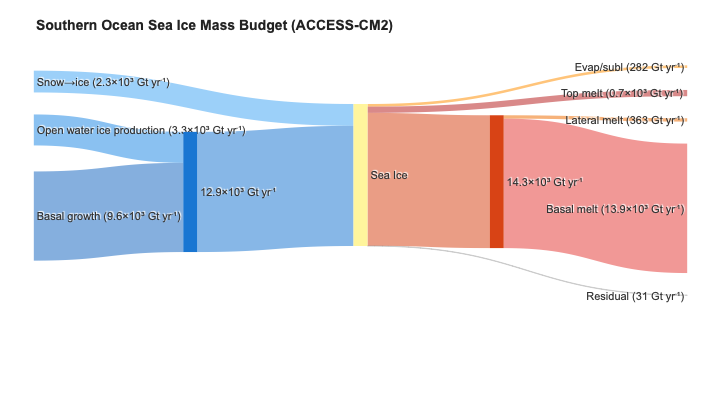

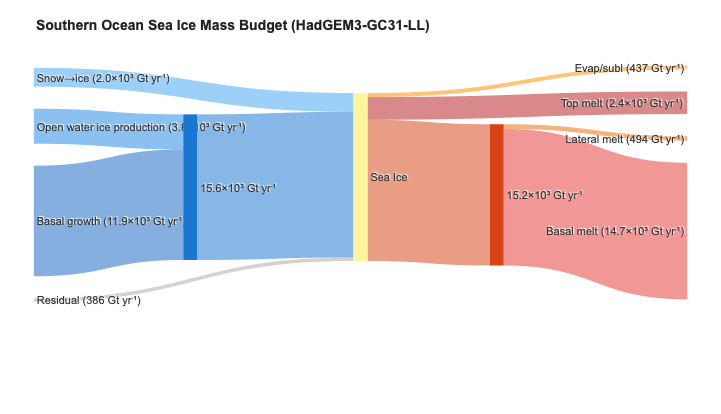

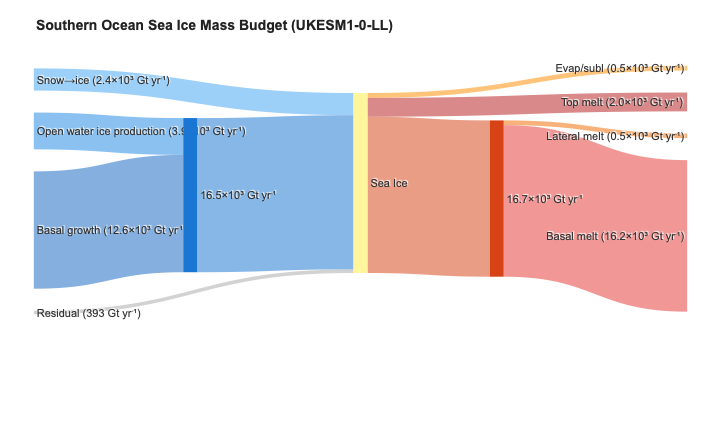

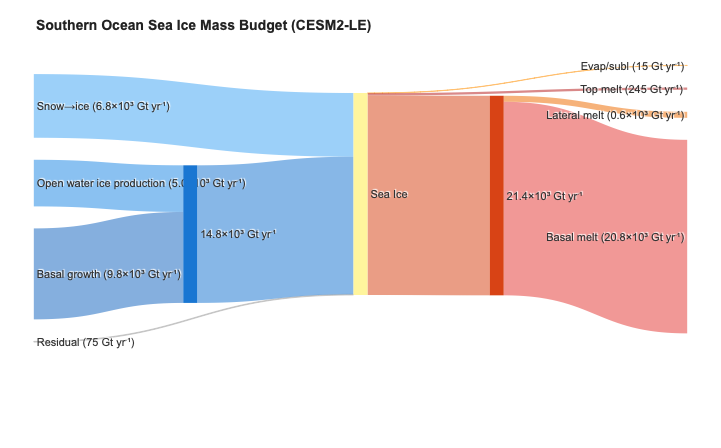

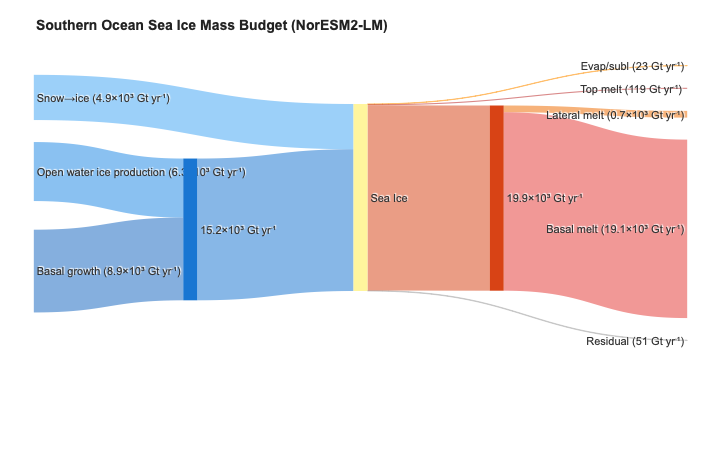

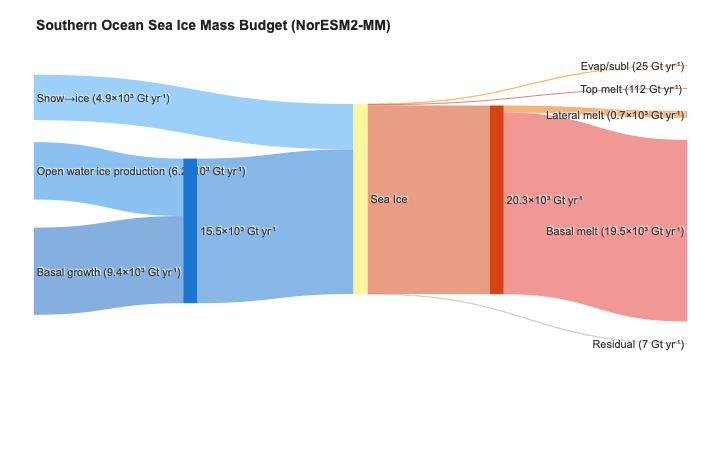

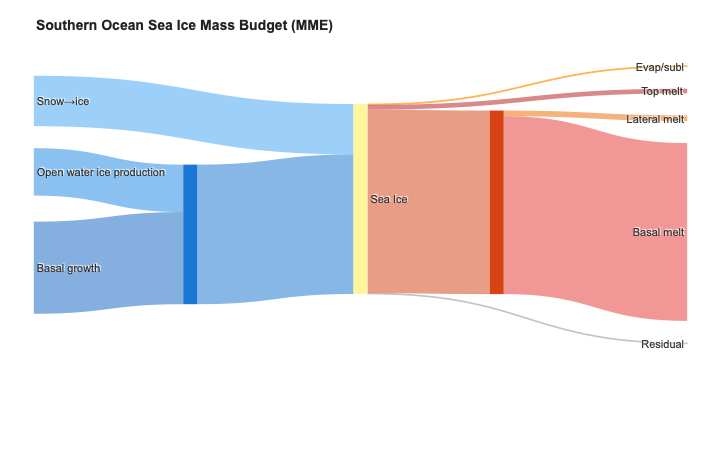

In [14]:
# ── Plotly Sankey: ice mass budget ────────────────────────────────────────────
for _model in SANKEY_MODELS + [None]:
    _show_vals = SHOW_VALUES_MME if _model is None else True
    fig = make_ice_sankey_plotly(
        ice_budget_SH, model=_model, res_label="Sea Ice",
        scale_ref=ICE_SANKEY_SCALE_REF, res_color="#FFF59D",
        show_values=_show_vals, show_residual=SHOW_RESIDUAL,
        hide_terminal_nodes=True,
        subtitle="Southern Ocean",
    )
    label = _model if _model is not None else "MME"
    fig.write_image(f"figures/ice_sankey_SO_{label}.png", scale=3.125)
    fig.write_image(f"figures/ice_sankey_SO_{label}.pdf")
    #fig.write_image(f"figures/ice_sankey_SO_{label}.svg")
    fig.show()

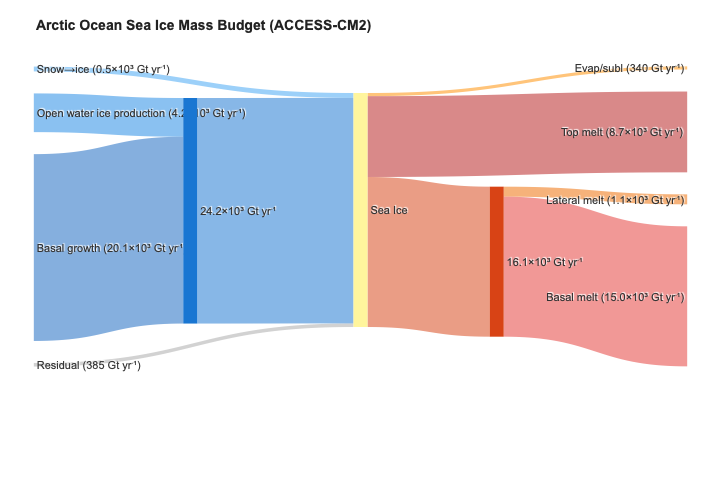

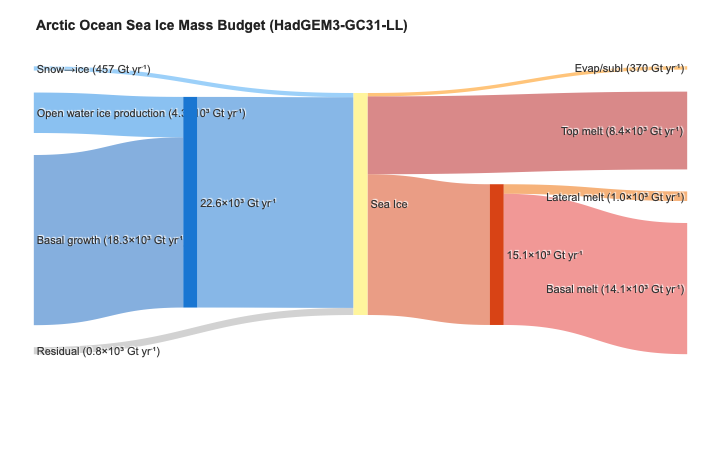

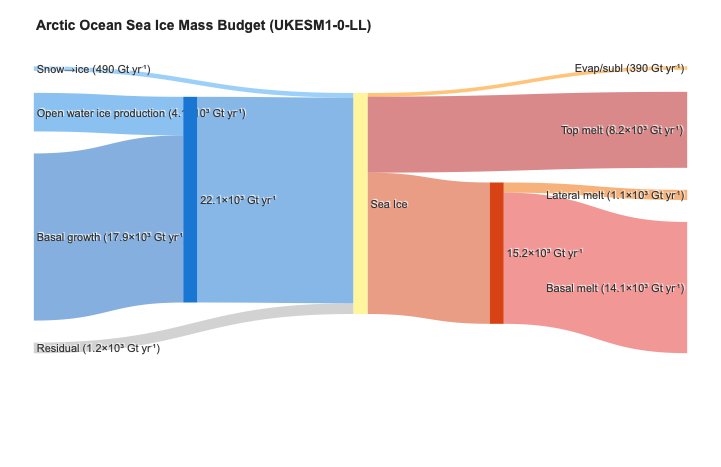

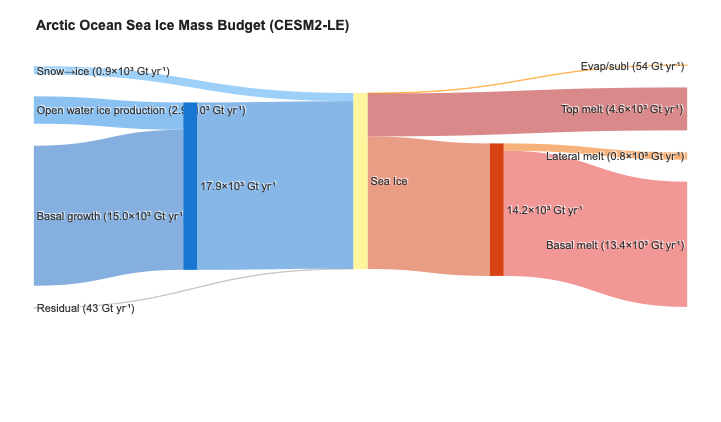

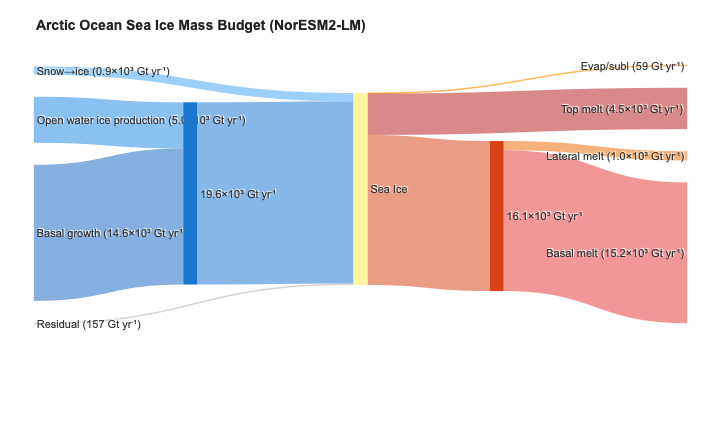

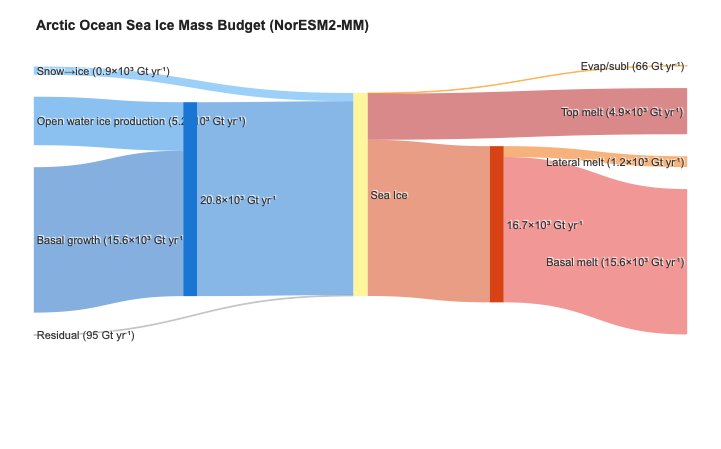

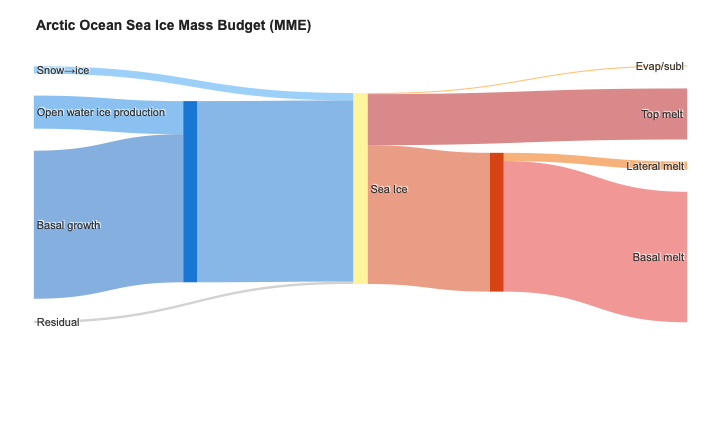

In [15]:
# ── Plotly Sankey: ice mass budget ────────────────────────────────────────────
for _model in SANKEY_MODELS + [None]:
    _show_vals = SHOW_VALUES_MME if _model is None else True
    fig = make_ice_sankey_plotly(
        ice_budget_NH, model=_model, res_label="Sea Ice",
        scale_ref=ICE_SANKEY_SCALE_REF, res_color="#FFF59D",
        show_values=_show_vals, show_residual=SHOW_RESIDUAL,
        hide_terminal_nodes=True,
        subtitle="Arctic Ocean",
    )
    label = _model if _model is not None else "MME"
    fig.write_image(f"figures/ice_sankey_AO_{label}.png", scale=3.125)
    fig.write_image(f"figures/ice_sankey_AO_{label}.pdf")
    #fig.write_image(f"figures/ice_sankey_AO_{label}.svg")
    fig.show()

### Snow Mass Budget

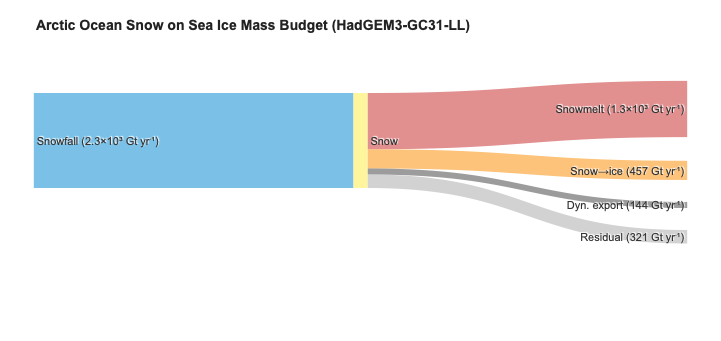

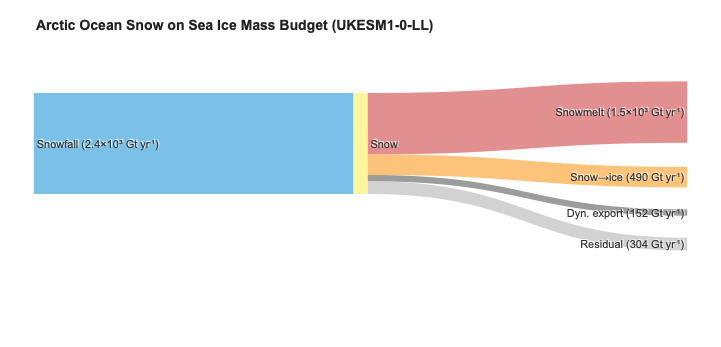

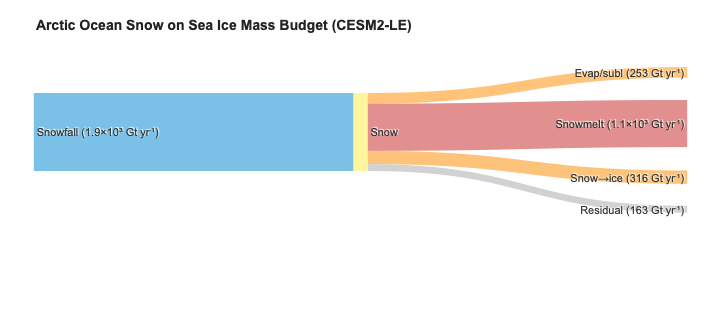

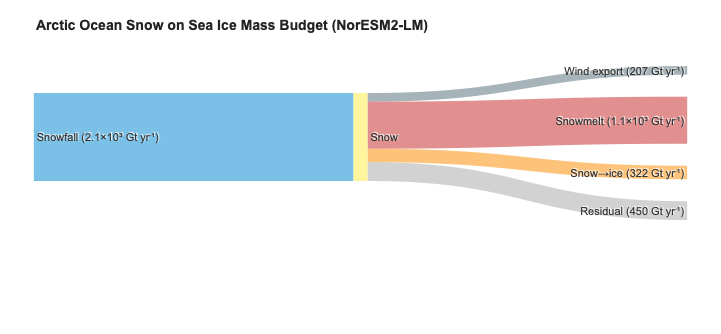

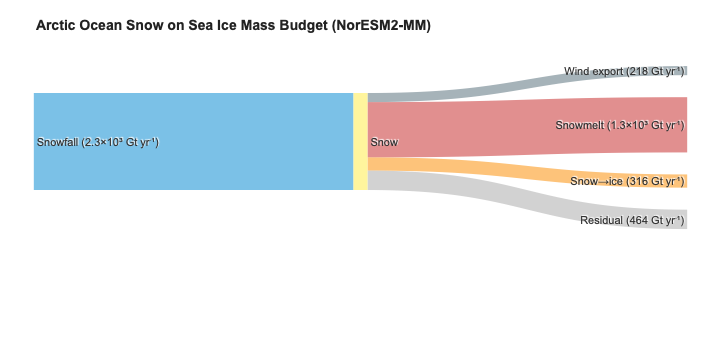

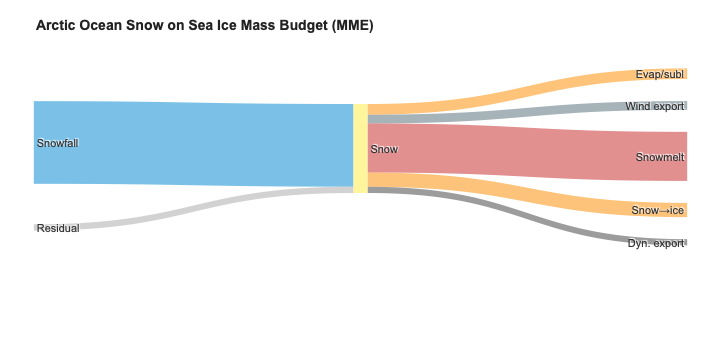

In [16]:
# ── Plotly Sankey: snow mass budget ───────────────────────────────────────────
for _model in SANKEY_MODELS + [None]:
    skip = ['ACCESS-CM2']
    if _model in skip:
        continue
    _show_vals = SHOW_VALUES_MME if _model is None else True
    fig = make_snow_sankey_plotly(
        {k: drop_sel(da, skip) for k, da in snow_budget_NH.items()}, model=_model,
        res_label="Snow", scale_ref=SNOW_SANKEY_SCALE_REF, res_color="#FFF59D",
        show_values=_show_vals, show_residual=SHOW_RESIDUAL,
        hide_terminal_nodes=True,
        subtitle="Arctic Ocean",
    )
    label = _model if _model is not None else "MME"
    fig.write_image(f"figures/snow_sankey_AO_{label}.png", scale=3.125)
    fig.write_image(f"figures/snow_sankey_AO_{label}.pdf")
    #fig.write_image(f"figures/snow_sankey_AO_{label}.svg")
    fig.show()

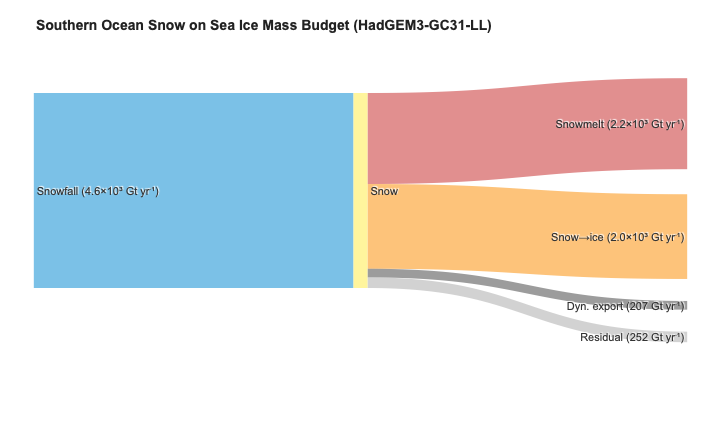

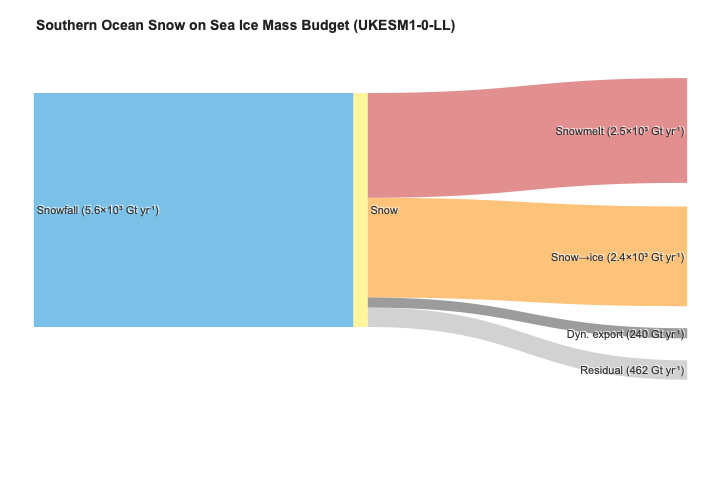

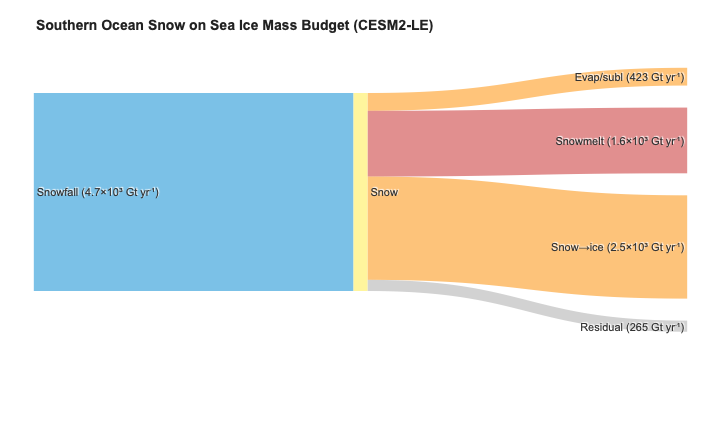

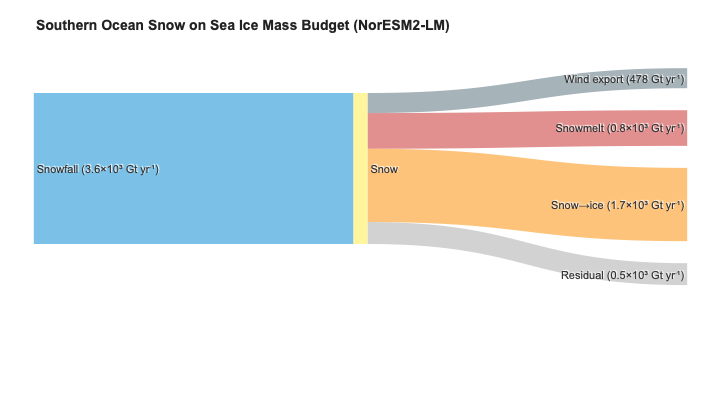

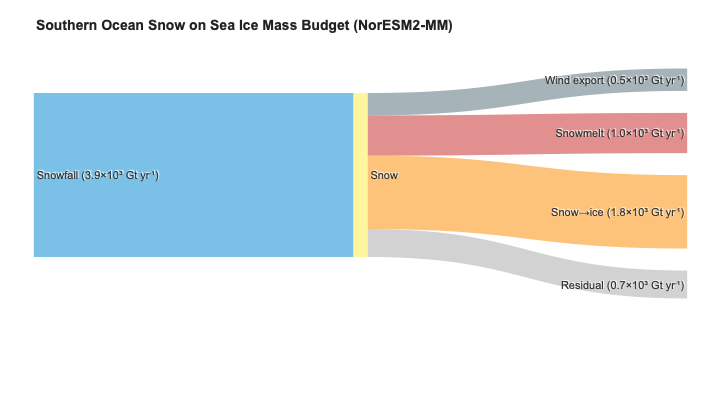

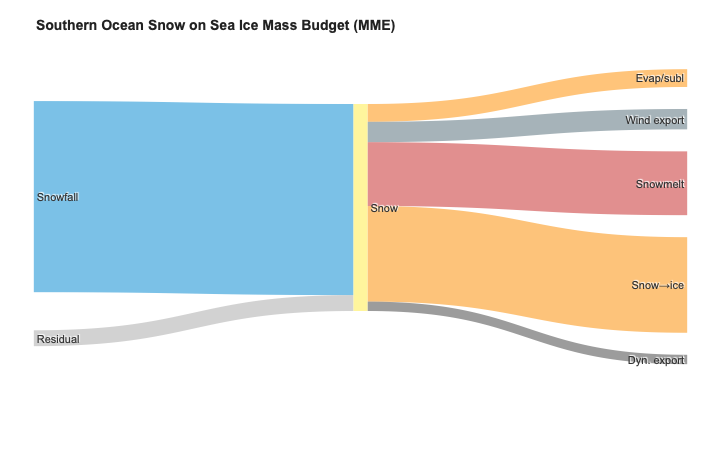

In [17]:
# ── Plotly Sankey: snow mass budget ───────────────────────────────────────────
for _model in SANKEY_MODELS + [None]:
    skip = ['ACCESS-CM2']
    if _model in skip:
        continue
    _show_vals = SHOW_VALUES_MME if _model is None else True
    fig = make_snow_sankey_plotly(
        {k: drop_sel(da, skip) for k, da in snow_budget_SH.items()}, model=_model,
        res_label="Snow", scale_ref=SNOW_SANKEY_SCALE_REF, res_color="#FFF59D",
        show_values=_show_vals, show_residual=SHOW_RESIDUAL,
        hide_terminal_nodes=True,
        subtitle="Southern Ocean",
    )
    label = _model if _model is not None else "MME"
    fig.write_image(f"figures/snow_sankey_SO_{label}.png", scale=3.125)
    fig.write_image(f"figures/snow_sankey_SO_{label}.pdf")
    #fig.write_image(f"figures/snow_sankey_SO_{label}.svg")
    fig.show()